DEPOLARIZE1(0.0333333) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36
H 0
CX 0 24
DEPOLARIZE2(0.05) 0 24
CX 0 1
DEPOLARIZE2(0.05) 0 1
CX 1 2
DEPOLARIZE2(0.05) 1 2
CX 2 3
DEPOLARIZE2(0.05) 2 3
CX 2 25
DEPOLARIZE2(0.05) 2 25
CX 2 26
DEPOLARIZE2(0.05) 2 26
CX 2 27
DEPOLARIZE2(0.05) 2 27
CX 1 4
DEPOLARIZE2(0.05) 1 4
CX 1 5
DEPOLARIZE2(0.05) 1 5
CX 5 28
DEPOLARIZE2(0.05) 5 28
CX 5 6
DEPOLARIZE2(0.05) 5 6
CX 5 7
DEPOLARIZE2(0.05) 5 7
CX 7 29
DEPOLARIZE2(0.05) 7 29
CX 5 30
DEPOLARIZE2(0.05) 5 30
CX 5 31
DEPOLARIZE2(0.05) 5 31
CX 1 8
DEPOLARIZE2(0.05) 1 8
CX 1 32
DEPOLARIZE2(0.05) 1 32
CX 1 33
DEPOLARIZE2(0.05) 1 33
CX 1 34
DEPOLARIZE2(0.05) 1 34
CX 0 9
DEPOLARIZE2(0.05) 0 9
CX 0 10
DEPOLARIZE2(0.05) 0 10
CX 10 11
DEPOLARIZE2(0.05) 10 11
CX 10 12
DEPOLARIZE2(0.05) 10 12
CX 12 35
DEPOLARIZE2(0.05) 12 35
CX 12 28
DEPOLARIZE2(0.05) 12 28
DEPOLARIZE1(0.0333333) 28
M 28
DETECTOR rec[-1]
CX 10 13
DEPOLARIZE2(0.05) 10 13
CX 10 14
DEPOLARIZE2(0.05)

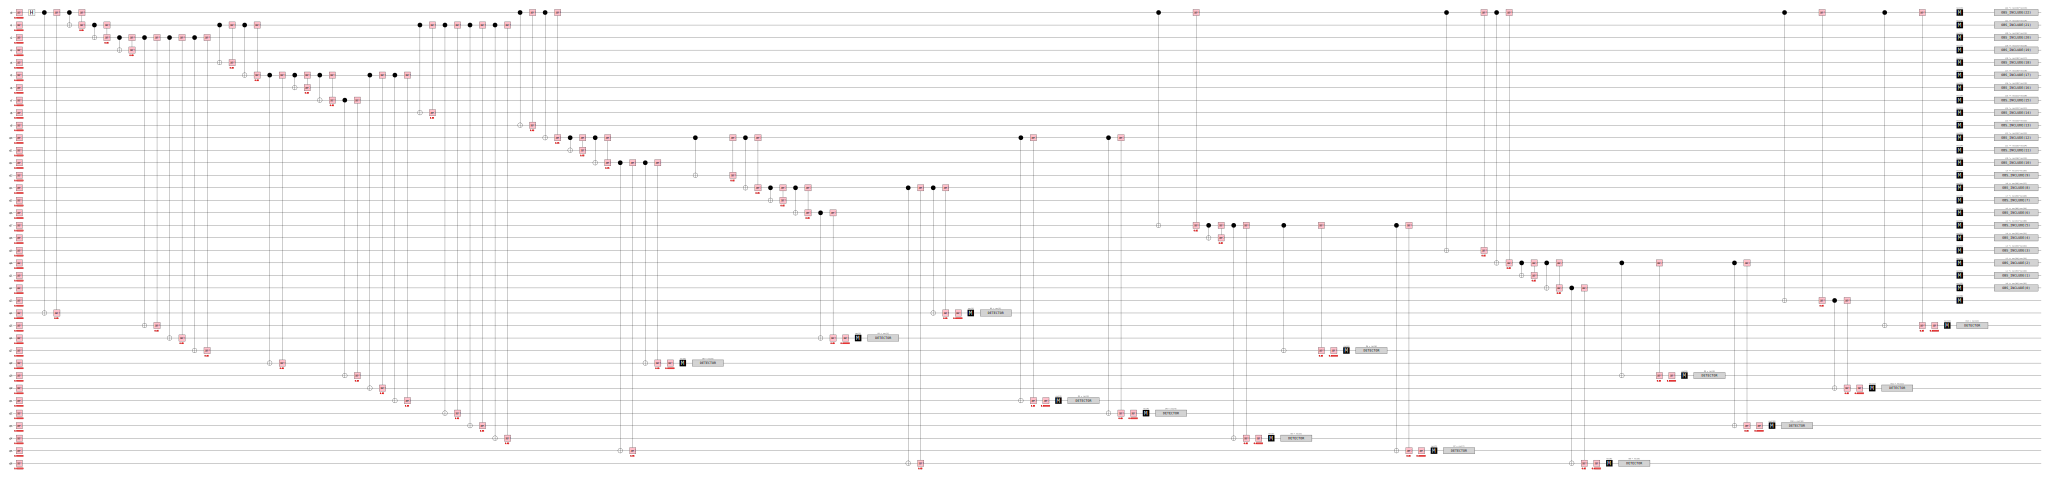

In [3]:
from spidercat.simulate import add_measurements
from spidercat.circuit_extraction import make_stim_circ_noisy

import stim

n = 24
p = 0.05
with open(f"../spidercat/circuits/cat_state_t5_n{n}_p1.stim", "r") as f:
    circ = stim.Circuit(f.read())


noisy_circ = make_stim_circ_noisy(circ, p_2=p, p_init=2 / 3 * p, p_meas=2 / 3 * p, p_mem=0)
add_measurements(noisy_circ, n, "spider-cat")
for i in range(n - 1):
    noisy_circ.append("OBSERVABLE_INCLUDE", [stim.target_rec(-1 - i), stim.target_rec(-2 - i)],i)

print(noisy_circ)
noisy_circ.append("MPP", [])
noisy_circ.diagram('timeline-svg')

In [2]:
noisy_circ.detector_error_model()

stim.DetectorErrorModel('''
    error(0.0678058) D0
    error(0.0266667) D0 D1 D2 D3 D4 D5 D6 D9 D10 D11 D12 L13 L22
    error(0.0266667) D0 D1 D2 D3 D4 D5 D6 D9 D10 D11 D12 L14 L22
    error(0.0266667) D0 D1 D2 D3 D4 D7 D8 L6 L11 L12 L13
    error(0.0477037) D0 D1 D2 D3 D4 D7 D8 L6 L13
    error(0.0477037) D0 D1 D3 D4 D5 D6 D9 D10 D11 D12 L14 L22
    error(0.0266667) D0 D3 D4 D5 D9 D10 D11 L14 L18 L21 L22
    error(0.0266667) D0 D3 D4 D5 D9 D10 D11 L14 L19 L21 L22
    error(0.0477037) D0 D3 D9 D11 L15 L18
    error(0.0477037) D0 D7 L10 L11
    error(0.0266667) D0 L10 L11
    error(0.0678058) D1
    error(0.0266667) D1 D2 D3 D4 D8 L6 L9 L12 L13
    error(0.0266667) D1 D2 D3 D4 D8 L6 L10 L12 L13
    error(0.0266667) D1 D2 D8 L6 L7 L8 L9
    error(0.0477037) D1 D2 D8 L6 L9
    error(0.0477037) D1 D6 D12 L19 L21
    error(0.0266667) D1 D6 D12 L20 L21
    error(0.0266667) D1 D6 L20 L21
    error(0.0477037) D1 L6 L7
    error(0.0908561) D2
    error(0.0266667) D2 D8 L8 L9
    error(0.026666

In [2]:
import os
import tesseract_decoder
import tesseract_decoder.tesseract as tesseract
import numpy as np

from contextlib import contextmanager

@contextmanager
def suppress_c_stdout_stderr():
    # Open a dummy file to route the output into the void
    devnull = os.open(os.devnull, os.O_WRONLY)

    # Save the actual file descriptors for stdout (1) and stderr (2)
    old_stdout = os.dup(1)
    old_stderr = os.dup(2)

    try:
        # Overwrite stdout and stderr with devnull
        os.dup2(devnull, 1)
        os.dup2(devnull, 2)
        yield
    finally:
        # Restore the original stdout and stderr
        os.dup2(old_stdout, 1)
        os.dup2(old_stderr, 2)

        # Clean up the file descriptors
        os.close(devnull)
        os.close(old_stdout)
        os.close(old_stderr)


def get_num_errors(observables):
    num_shots = observables.shape[0]
    n = observables.shape[1] + 1
    relative_errors = np.cumsum(observables, axis=1) % 2
    zeros_column = np.zeros((num_shots, 1), dtype=int)
    full_error_strings = np.hstack((zeros_column, relative_errors))
    weight_ones = np.sum(full_error_strings, axis=1)
    return np.minimum(weight_ones, n - weight_ones)


def run_tesseract_decoder(decoder, dets, obs):
    print("Raw Samples")
    print(f"Average number of qubit-flips: {np.average(get_num_errors(obs)):.2f}")
    print(f"Probability of more than 5 qubit-flips: {np.average(get_num_errors(obs) > 5):.2%}")
    print()
    print("Post-Selected Samples")
    print(f"Average number of qubit-flips: {np.average(get_num_errors(obs[~np.any(dets, axis=1)])):.2f}")
    print(f"Probability of more than 5 qubit-flips: {np.average(get_num_errors(obs[~np.any(dets, axis=1)]) > 5):.2%}")
    print()
    obs_predicted = decoder.decode_batch(dets)
    print("Decoded Samples")
    print(f"Average number of qubit-flips: {np.average(get_num_errors(obs_predicted != obs)):.2f}")
    print(f"Probability of more than 5 qubit-flips: {np.average(get_num_errors(obs_predicted != obs) > 5):.2%}")


num_shots = 100_000
sampler = noisy_circ.compile_detector_sampler()
detector_outcomes, actual_observables = sampler.sample(shots=num_shots, separate_observables=True)
dem = noisy_circ.detector_error_model(decompose_errors=True)


# setup the tesseract decoder configuration
tesseract_config = tesseract.TesseractConfig(
    dem=dem,
    pqlimit=10000,
    no_revisit_dets=True,
    # verbose=True,
    det_orders=tesseract_decoder.utils.build_det_orders(
        dem, num_det_orders=1,
        method=tesseract_decoder.utils.DetOrder.DetIndex,
        seed=2384753),
)

with suppress_c_stdout_stderr():
    tesseract_dec = tesseract_config.compile_decoder()

results = run_tesseract_decoder(tesseract_dec, detector_outcomes, actual_observables)

Raw Samples
Average number of qubit-flips: 4.11
Probability of more than 5 qubit-flips: 30.56%

Post-Selected Samples
Average number of qubit-flips: 0.61
Probability of more than 5 qubit-flips: 0.02%

Decoded Samples
Average number of qubit-flips: 1.89
Probability of more than 5 qubit-flips: 5.62%


In [18]:
import stim

def CSS_make_circuit(stabilizers, logical_paulis, obs_type):
    """
    Make a distance computation circuit for a CSS code.
    This circuit alone does not solve the distance finding problem.
    You'll have to run it twice --- once for Z-type stabs/logicals and once for X-type.

    Input in a CSS stabilizer code in stim representation, a set of logical Paulis which are
    all 'X'-type ('Z'-type) and set `obs_type` to 'X' ('Z').

    Params:
        * stabilizers (list[stim.PauliString]): stabilizer tableau given as a list of Paulis in stim form.
        * logical_paulis (list[stim.PauliString]): logical paulis list in stim form.
        * obs_type (str): either 'Z' or 'X'. Specifies whether the logicals are X-type or Z-type.

    Returns:
        * stim.Circuit representing an error simulation and detection circuit for the code.

    Adapted from code written by Craig Gidney on StackExchange.
    https://quantumcomputing.stackexchange.com/questions/37289/compute-the-exact-minimum-distance-of-a-qecc-with-integer-linear-programming-met
    """
    assert obs_type in ['Z', 'X'], f"obs_type should be 'Z' or 'X', but is {obs_type}"
    num_qubits = len(stabilizers[0])
    circuit = stim.Circuit()
    stab_record_step = 1

    for stabilizer in stabilizers:
        if stabilizer.pauli_indices(obs_type):
            circuit.append("MPP", stim.target_combined_paulis(stabilizer))
            stab_record_step += 1

    for k, observable in enumerate(logical_paulis):
        X_part, Z_part = stim.PauliString.to_numpy(observable)
        stim_obs = []
        for i, (x, z) in enumerate(zip(X_part, Z_part)):
            if x and z:
                stim_obs.append(stim.target_y(i))
            elif x:
                stim_obs.append(stim.target_x(i))
            elif z:
                stim_obs.append(stim.target_z(i))
        circuit.append("OBSERVABLE_INCLUDE", stim_obs, k)

    ERROR_TYPE = 'X' if obs_type == 'Z' else 'Z'

    circuit.append(f"{ERROR_TYPE}_ERROR", range(num_qubits), 1e-3)

    for stabilizer in stabilizers:
        if stabilizer.pauli_indices(obs_type):
            circuit.append('MPP', stim.target_combined_paulis(stabilizer))
            circuit.append('DETECTOR', [stim.target_rec(-stab_record_step), stim.target_rec(-1)])

    for k, observable in enumerate(logical_paulis):
        X_part, Z_part = stim.PauliString.to_numpy(observable)
        stim_obs = []
        for i, (x, z) in enumerate(zip(X_part, Z_part)):
            if x and z:
                stim_obs.append(stim.target_y(i))
            elif x:
                stim_obs.append(stim.target_x(i))
            elif z:
                stim_obs.append(stim.target_z(i))
        circuit.append("OBSERVABLE_INCLUDE", stim_obs, k)

    return circuit


circ = CSS_make_circuit([
      stim.PauliString("XXXXIII"),
      stim.PauliString("IXXIXXI"),
      stim.PauliString("IIXXIXX"),
      stim.PauliString("ZZZZIII"),
      stim.PauliString("IZZIZZI"),
      stim.PauliString("IIZZIZZ"),
  ], [
      # stim.PauliString("IIIIXXX"),
      # stim.PauliString("IIIIZZZ"),
      stim.PauliString("XIIIIII"),
      stim.PauliString("IXIIIII"),
      stim.PauliString("IIXIIII"),
      stim.PauliString("IIIXIII"),
      stim.PauliString("IIIIXII"),
      stim.PauliString("IIIIIXI"),
      stim.PauliString("IIIIIIX"),
  ], "Z")

print(circ.detector_error_model())
circ.diagram("timeline-svg")

ValueError: The circuit contains non-deterministic observables.

To make an SVG picture of the problem, you can use the python API like this:
    your_circuit.diagram('detslice-with-ops-svg', tick=range(0, 5), filter_coords=['L2', 'L3', 'L5', 'L6', ])
or the command line API like this:
    stim diagram --in your_circuit_file.stim --type detslice-with-ops-svg --tick 0:5 --filter_coords L2:L3:L5:L6 > output_image.svg

This was discovered while analyzing a Pauli product measurement (MPP) on:
    qubit 2

The collapse anti-commuted with these detectors/observables:
    L2
    L3
    L5
    L6

The backward-propagating error sensitivity for L2 was:
    X2

The backward-propagating error sensitivity for L3 was:
    X2
    X3

The backward-propagating error sensitivity for L5 was:
    X2
    X5

The backward-propagating error sensitivity for L6 was:
    X2
    X6

Circuit stack trace:
    at instruction #14 [which is MPP Z2*Z3*Z5*Z6]